# Trabajo práctico 2 - Minería de Datos - Modelo de Regresión
Primer Cuatrimestre - Año 2026

Integrantes:

- Lara Onyskiw
- Sebastián Muñoz

### Importación de paquetes y carga del dataset

In [94]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

Agregamos esta ruta para que Python pueda encontrar el ejecutable de Graphviz y generar la visualización del árbol dentro del notebook.

In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn.tree import export_graphviz
from graphviz import Source

In [96]:
dataCompanies = pd.read_csv("1000_Companies.csv")

dataCompanies.head()

,RyD_Spend,Administration,MarketingSpend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


### Análisis exploratorio y limpieza de datos

Comenzamos cargando el conjunto de datos correspondiente a empresas y ganancias. En esta primera revisión buscamos conocer su dimensión, los tipos de variables disponibles y la presencia de posibles problemas iniciales, como valores faltantes o registros duplicados.

Esta etapa nos permite decidir si es necesario aplicar alguna limpieza antes de avanzar con las visualizaciones y el modelado.

In [97]:
print(f"Filas, columnas: {dataCompanies.shape} \n ")
print(f"Tipos de datos: \n {dataCompanies.dtypes}")

Filas, columnas: (1000, 5) 
 
Tipos de datos: 
 RyD_Spend         float64
Administration    float64
MarketingSpend    float64
State                 str
Profit            float64
dtype: object


In [98]:
# Faltantes
print(f"Cantidad de valores nulos por columna: \n {dataCompanies.isna().sum()}")

Cantidad de valores nulos por columna: 
 RyD_Spend         0
Administration    0
MarketingSpend    0
State             0
Profit            0
dtype: int64


In [99]:
# Duplicados
print(f"Cantidad de registros duplicados: {dataCompanies.duplicated().sum()}")

display(dataCompanies[dataCompanies.duplicated(keep=False)].sort_values(by=list(dataCompanies.columns)))

Cantidad de registros duplicados: 1


,RyD_Spend,Administration,MarketingSpend,State,Profit
335,84533.0,122941.3141,231885.6935,California,121248.7116
755,84533.0,122941.3141,231885.6935,California,121248.7116


Al revisar los registros duplicados observamos que existe una fila repetida de manera exacta, no solo en las variables predictoras sino también en la variable objetivo Profit. Como el dataset no incluye un identificador que permita distinguir si se trata de dos empresas diferentes con valores idénticos, interpretamos esta repetición como una redundancia del conjunto de datos. Decidimos eliminar una de las copias para evitar que ese caso tenga mayor peso durante el entrenamiento y para reducir el riesgo de que el mismo registro aparezca simultáneamente en entrenamiento y prueba.

In [100]:
dataCompanies = dataCompanies.drop_duplicates()
print("Dimensión luego de eliminar duplicados:", dataCompanies.shape)

Dimensión luego de eliminar duplicados: (999, 5)


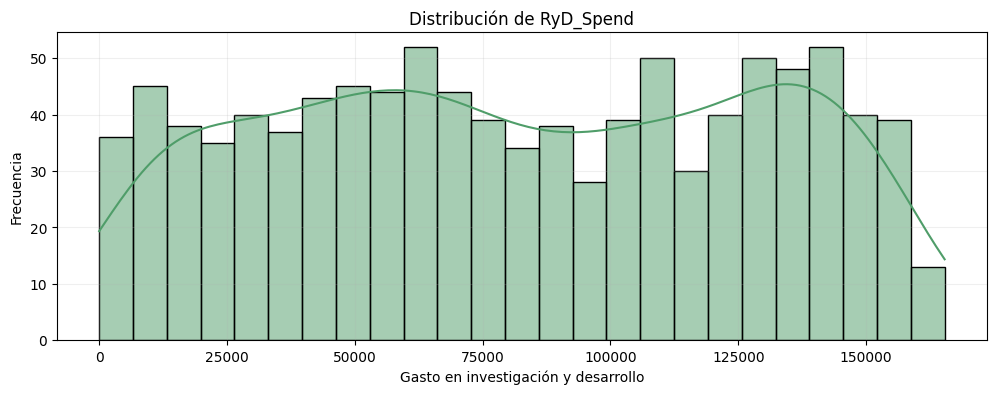

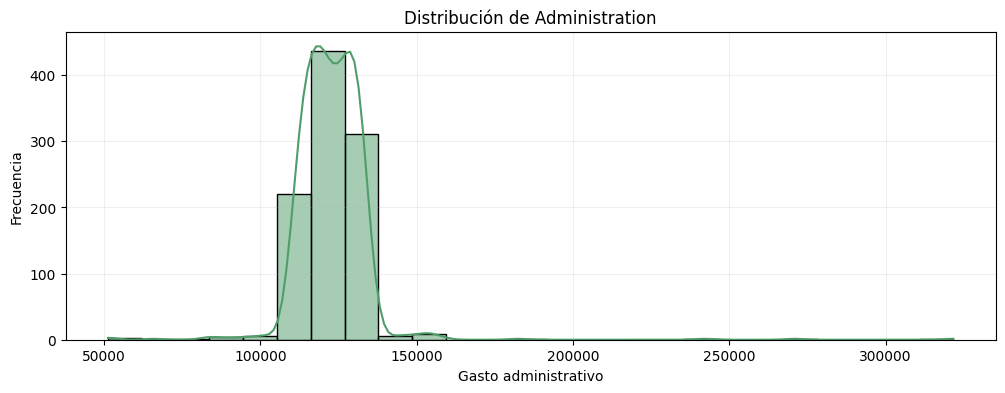

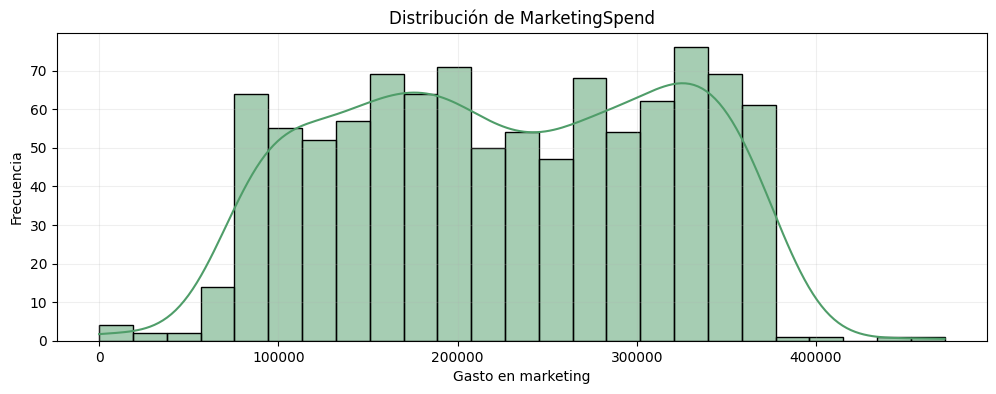

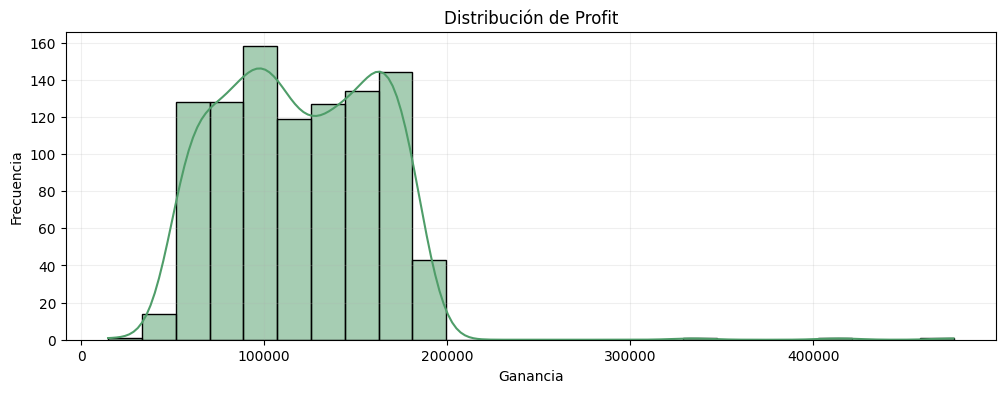

In [101]:
columnas_num = ["RyD_Spend", "Administration", "MarketingSpend", "Profit"]

etiquetas = {
    "RyD_Spend": "Gasto en investigación y desarrollo",
    "Administration": "Gasto administrativo",
    "MarketingSpend": "Gasto en marketing",
    "Profit": "Ganancia"
}


for col in columnas_num:
    plt.figure(figsize=(12, 4))

    sns.histplot(
        data=dataCompanies,
        x=col,
        bins=25,
        kde=True,
        color="#4f9d69"
    )

    plt.title("Distribución de " + col)
    plt.xlabel(etiquetas[col])
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)
    plt.show()

Comenzamos el análisis visual observando la distribución de las variables cuantitativas continuas mediante histogramas. Decidimos generar un gráfico por variable para que cada escala pueda leerse con claridad y para que los ejes queden identificados de manera explícita.

En estos gráficos, el eje horizontal representa los valores de cada variable y el eje vertical muestra la frecuencia de observaciones dentro de cada intervalo. Esta primera lectura nos permite reconocer concentraciones, posibles asimetrías y comportamientos generales antes de analizar relaciones entre variables.

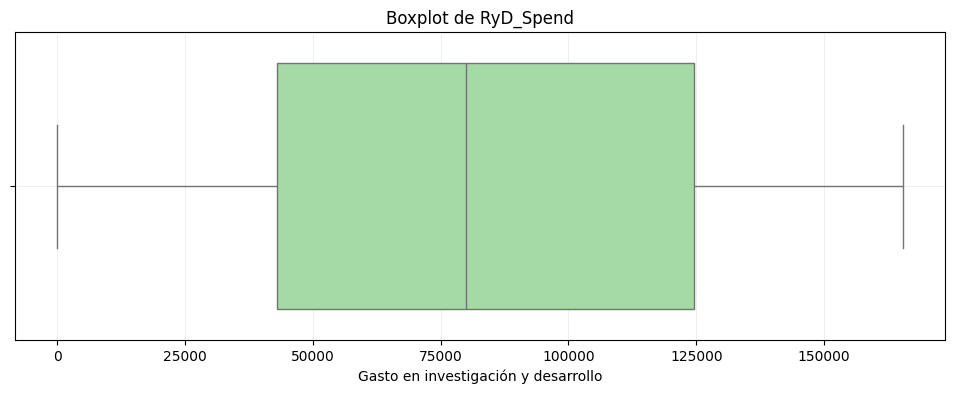

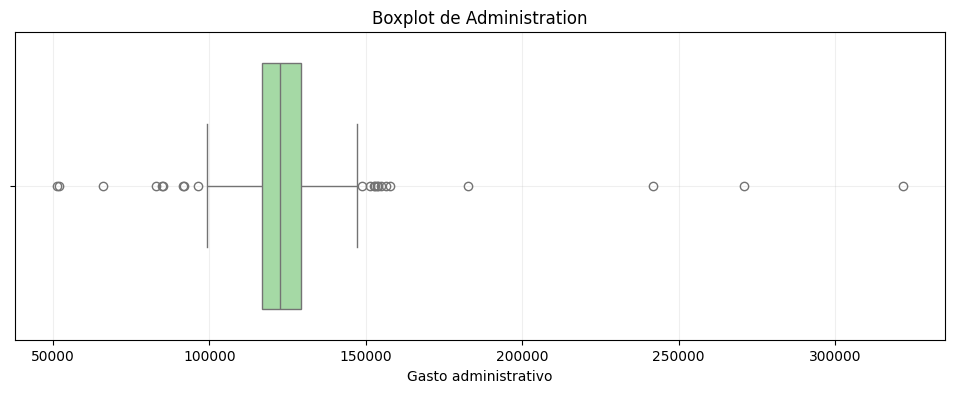

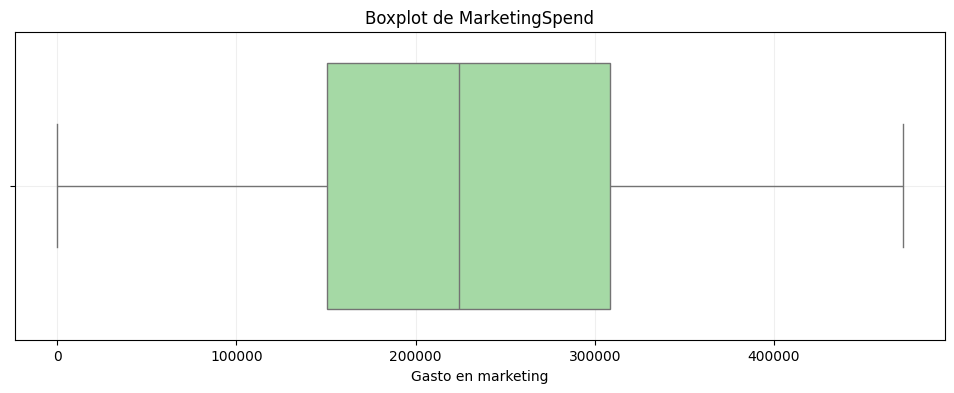

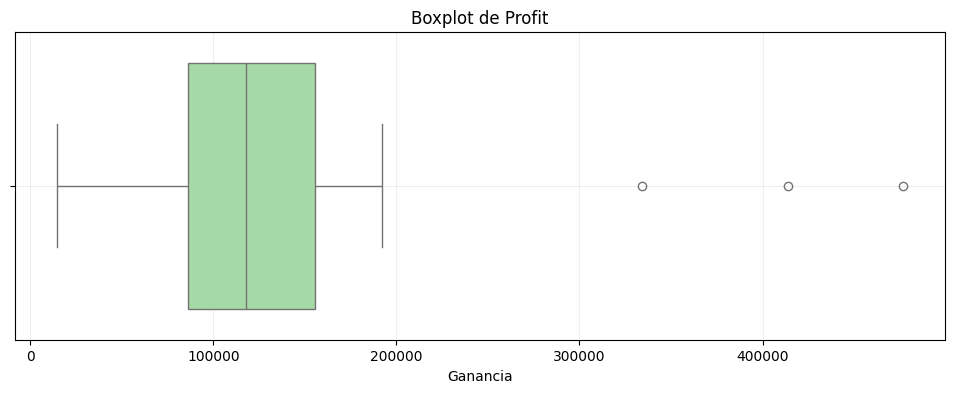

In [102]:
for col in columnas_num:
    plt.figure(figsize=(12, 4))

    sns.boxplot(
        data=dataCompanies,
        x=col,
        color="#9ce29c"
    )

    plt.title("Boxplot de " + col)
    plt.xlabel(etiquetas[col])
    plt.grid(alpha=0.2)
    plt.show()

Después de observar las distribuciones, analizamos posibles valores extremos mediante boxplots horizontales. Elegimos esta orientación porque las variables representan montos monetarios y, al extenderse sobre el eje horizontal, la escala resulta más legible.

El objetivo de estos gráficos no es eliminar datos automáticamente, sino identificar observaciones que se separan del comportamiento general. En este caso, al tratarse de datos financieros, un valor extremo puede representar una empresa con gastos o ganancias particularmente altos, y no necesariamente un error de carga.

In [103]:
dataCompanies.describe(percentiles=[0.001, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995])

,RyD_Spend,Administration,MarketingSpend,Profit
count,999.000000,999.000000,999.000000,999.000000
mean,81666.060260,122963.920218,226199.372097,119544.460404
std,46560.789116,12620.245535,91624.086386,42910.081882
min,0.000000,51283.140000,0.000000,14681.400000
0.1%,0.000000,51742.229980,0.000000,35631.425980
25%,43081.000000,116639.540300,150727.914400,85909.667605
50%,79898.000000,122417.624700,224192.766100,117637.622000
75%,124593.000000,129141.554800,308485.022450,155635.604950
90%,144416.000000,132116.364780,348309.958780,172795.798640
95%,153457.959000,133376.985400,365189.634630,180535.507630


Al observar los registros que superan el límite superior de 'Profit', identificamos tres empresas con ganancias muy alejadas del resto del conjunto. Si bien estos valores no son imposibles desde el punto de vista financiero, se separan de manera marcada del comportamiento general observado en el dataset.

Además, estos registros no aparecen aislados solo en 'Profit', sino que también presentan valores elevados en 'Administration', lo que refuerza la idea de que corresponden a casos atípicos dentro de esta base. Dado que el objetivo del trabajo es construir un modelo que represente el comportamiento general de las empresas, decidimos eliminar estos outliers severos para evitar que tengan una influencia desproporcionada en el entrenamiento y en métricas sensibles a errores grandes, como MSE y RMSE.

Para complementar la lectura visual de los boxplots, calculamos el límite superior de 'Profit' mediante el criterio del rango intercuartílico. Utilizamos este criterio como una guía estadística para identificar valores extremos, no como una regla automática de eliminación.

Antes de tomar una decisión, observamos cuáles son los registros que superan ese límite y si presentan coherencia con el resto de las variables financieras.

In [104]:
# Calculamos el límite superior por IQR para Profit
q1_profit = dataCompanies["Profit"].quantile(0.25)
q3_profit = dataCompanies["Profit"].quantile(0.75)

iqr_profit = q3_profit - q1_profit
limite_superior_profit = q3_profit + 1.5 * iqr_profit

limite_superior_profit

np.float64(260224.51096750004)

In [105]:
# Observamos los registros que superan ese límite
outliers_profit = dataCompanies[dataCompanies["Profit"] > limite_superior_profit]

outliers_profit

,RyD_Spend,Administration,MarketingSpend,State,Profit
997,100275.47,241926.31,227142.82,California,413956.48
998,128456.23,321652.14,281692.32,California,333962.19
999,161181.72,270939.86,295442.17,New York,476485.43


Al observar los registros que superan el límite superior de 'Profit', identificamos tres empresas con ganancias muy alejadas del resto del conjunto. Si bien estos valores no son imposibles desde el punto de vista financiero, se separan de manera marcada del comportamiento general observado en el dataset.

Además, estos registros también presentan valores elevados en 'Administration', por lo que no aparecen como casos extremos únicamente en la variable objetivo. Dado que buscamos construir un modelo que represente el comportamiento general de las empresas, decidimos eliminar estos outliers severos para evitar que tengan una influencia desproporcionada en el entrenamiento y en métricas sensibles a errores grandes, como MSE y RMSE.

In [106]:
# Eliminamos los registros con Profit superior al límite definido por IQR
dataCompanies = dataCompanies[dataCompanies["Profit"] <= limite_superior_profit]

# Reordenamos el índice luego de la eliminación
dataCompanies = dataCompanies.reset_index(drop=True)

print("Dimensión del dataset luego de eliminar outliers severos:", dataCompanies.shape)

Dimensión del dataset luego de eliminar outliers severos: (996, 5)


In [107]:
dataCompanies.describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.995])

,RyD_Spend,Administration,MarketingSpend,Profit
count,996.000000,996.000000,996.000000,996.000000
mean,81520.563032,122496.423682,226073.188168,118675.212695
std,46535.141677,9144.756564,91718.887094,39808.331643
min,0.000000,51283.140000,0.000000,14681.400000
25%,43056.000000,116636.180475,150136.039475,85839.615710
50%,79401.000000,122377.380650,223809.759850,117321.534150
75%,124079.000000,129060.069850,309128.511625,155032.518175
95%,152919.877500,133360.939450,365230.733025,180257.179500
99.5%,159243.975000,153520.593000,376678.279712,185274.710327
max,165349.200000,182645.560000,471784.100000,192261.830000


Luego de eliminar los tres registros extremos de 'Profit', volvemos a calcular el resumen estadístico para verificar cómo quedó conformado el dataset. Observamos que el valor máximo de 'Profit' pasa a ubicarse cerca de 192.000, mucho más próximo al percentil 99.5%, por lo que la variable objetivo queda menos afectada por casos aislados de ganancias excepcionalmente altas.

También vemos que 'Administration' conserva algunos valores altos, pero ya no presenta el mismo salto extremo que se observaba antes. Por este motivo, consideramos que la eliminación realizada fue puntual y no implicó una depuración excesiva del conjunto de datos.

A partir de este dataset depurado, avanzamos con los gráficos de dispersión entre las variables predictoras numéricas y 'Profit'. Esta visualización nos permite evaluar si, luego de la limpieza, se mantiene una relación clara entre los gastos de la empresa y la ganancia obtenida.

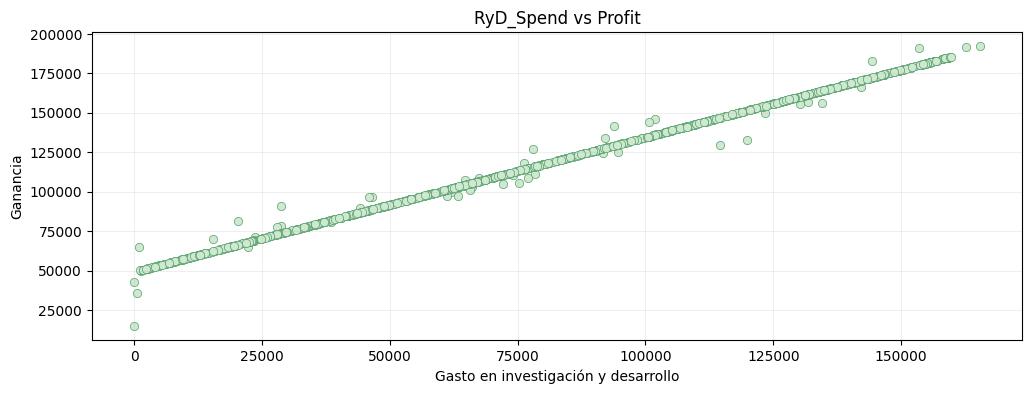

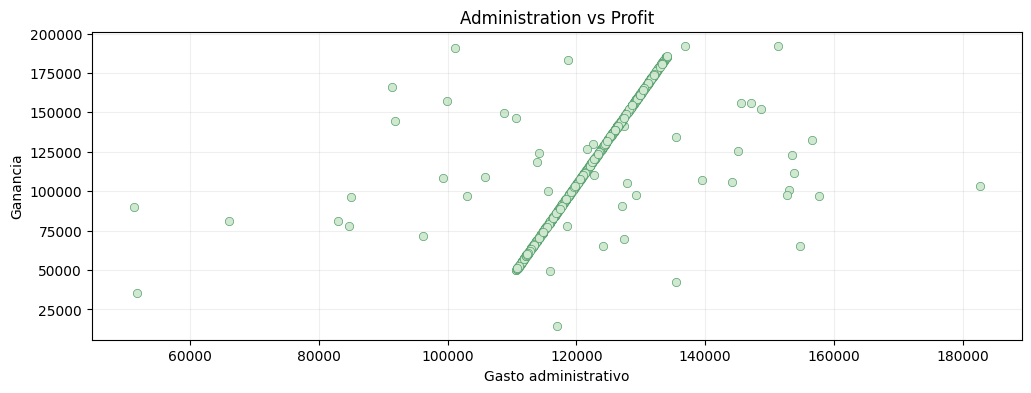

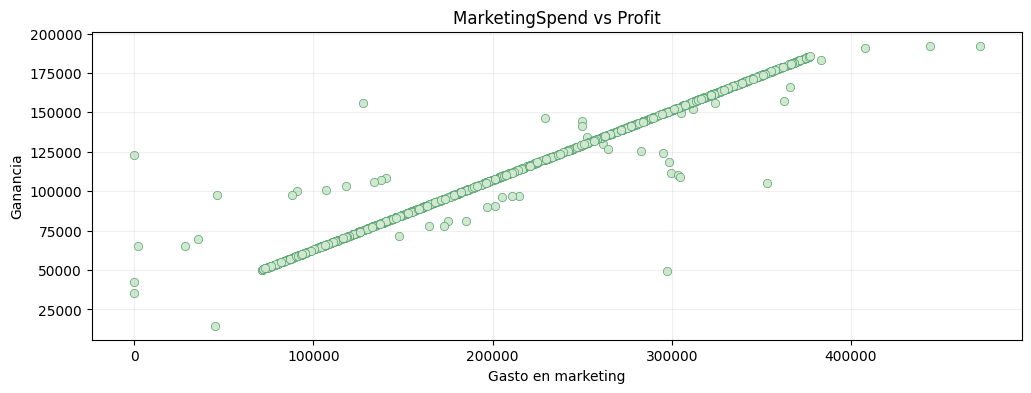

In [108]:
# Variables predictoras numéricas que vamos a comparar con Profit
variables_predictoras = ["RyD_Spend", "Administration", "MarketingSpend"]


for variable in variables_predictoras:
    plt.figure(figsize=(12, 4))

    sns.scatterplot(
        data=dataCompanies,
        x=variable,
        y="Profit",
        color="#cfe8cf",
        edgecolor="#4f9d69"
    )

    plt.title(variable + " vs Profit")
    plt.xlabel(etiquetas[variable])
    plt.ylabel("Ganancia")
    plt.grid(alpha=0.2)
    plt.show()

Luego de generar los gráficos de dispersión, observamos comportamientos diferentes entre las variables predictoras numéricas y 'Profit'.

En el caso de 'RyD_Spend', la relación con la ganancia es muy marcada: a medida que aumenta el gasto en investigación y desarrollo, también tiende a aumentar 'Profit'. Esta tendencia aparece de forma bastante ordenada, por lo que anticipamos que esta variable puede tener un peso importante en el modelo de regresión.

Para 'Administration', en cambio, la relación es mucho más dispersa. Los puntos no muestran una tendencia clara y aparecen empresas con distintos niveles de ganancia para valores administrativos similares. Esto sugiere que, por sí sola, esta variable no explica tan directamente el comportamiento de 'Profit'.

En 'MarketingSpend' observamos una relación positiva más visible que en 'Administration', aunque con mayor dispersión que en 'RyD_Spend'. En general, parece acompañar el crecimiento de la ganancia, pero no de manera tan precisa.

A partir de esta lectura, esperamos que el modelo de árbol de decisión utilice principalmente 'RyD_Spend' y, en menor medida, 'MarketingSpend' para estimar 'Profit', mientras que 'Administration' podría aportar menos información predictiva.

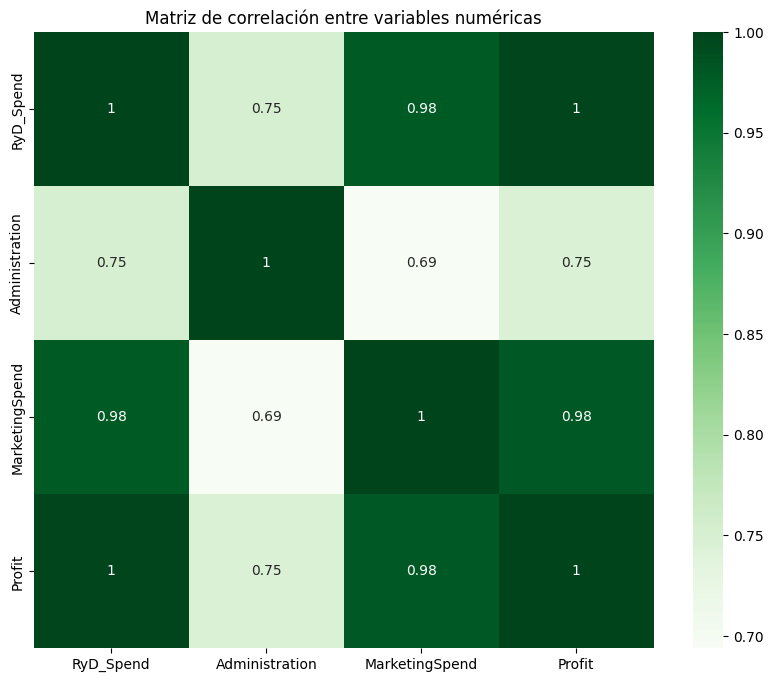

In [109]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    dataCompanies[["RyD_Spend", "Administration", "MarketingSpend", "Profit"]].corr(),
    annot=True,
    cmap="Greens"
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

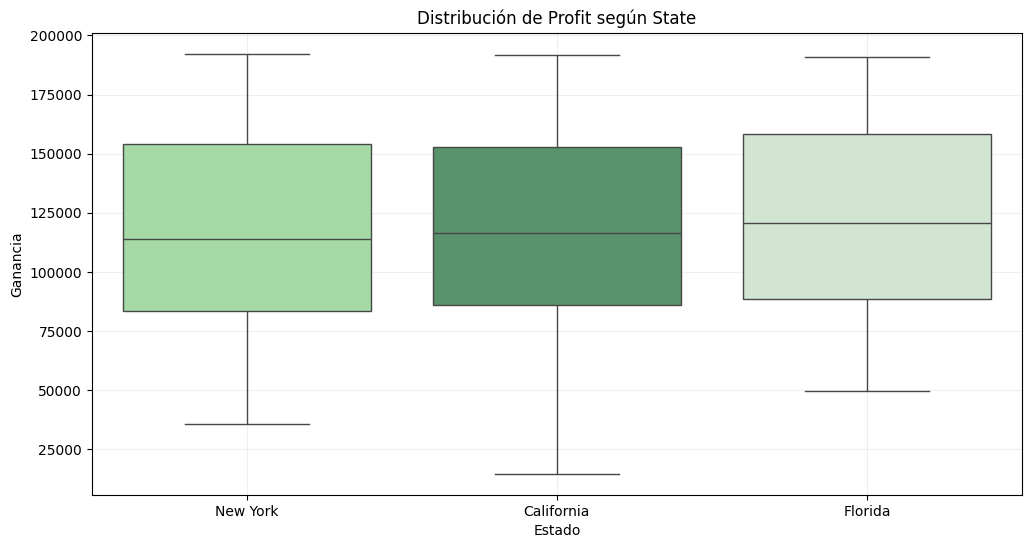

In [126]:
paleta = ["#9ce29c", "#4f9d69", "#cfe8cf"]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=dataCompanies,
    x="State",
    y="Profit",
    hue="State",
    palette=paleta,
    legend=False
)

plt.title("Distribución de Profit según State")
plt.xlabel("Estado")
plt.ylabel("Ganancia")
plt.grid(alpha=0.2)
plt.show()

La matriz de correlación confirma lo que ya veníamos observando en los gráficos de dispersión. 'RyD_Spend' presenta una relación muy fuerte con 'Profit', al punto de aparecer prácticamente alineada con la variable objetivo. 'MarketingSpend' también muestra una correlación elevada, aunque algo menor, por lo que esperamos que ambas variables sean relevantes para el modelo de regresión.

En el caso de 'Administration', la correlación con 'Profit' es positiva, pero más baja que en las otras dos variables. Esto coincide con la dispersión observada anteriormente, donde no se distinguía una relación tan directa entre el gasto administrativo y la ganancia.

Por otro lado, al analizar 'Profit' según 'State', no observamos diferencias demasiado marcadas entre los estados. Las distribuciones se superponen bastante y las medianas se mantienen en rangos similares, aunque Florida parece presentar una mediana levemente superior. Por este motivo, decidimos conservar 'State' como variable predictora, pero sin esperar que tenga el mismo peso explicativo que las variables numéricas principales.

Con este análisis dejamos cerrada la etapa exploratoria y avanzamos con la preparación final del dataset para el modelo.

### Codificación, estandarización y particiones del dataset

Luego del análisis exploratorio y de la limpieza inicial, avanzamos con la preparación del dataset para el modelo de regresión. En esta etapa separamos la variable objetivo 'Profit' de las variables predictoras, codificamos la variable categórica 'State' y estandarizamos las variables numéricas.

Si bien los árboles de decisión no dependen estrictamente del escalado de las variables, la consigna solicita normalizar o estandarizar las características numéricas. Por ese motivo aplicamos 'StandardScaler', cuidando que el ajuste del escalador se realice únicamente sobre los datos de entrenamiento para evitar incorporar información del conjunto de prueba.

In [111]:
# Separamos las variables predictoras y la variable objetivo
X = dataCompanies.drop("Profit", axis=1)
y = dataCompanies["Profit"]

# Codificamos la variable categórica State
X = pd.get_dummies(X, columns=["State"], drop_first=True, dtype=int)
X.columns = X.columns.str.replace(" ", "_")

X.head()

,RyD_Spend,Administration,MarketingSpend,State_Florida,State_New_York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0


Codificamos 'State' con variables dummies usando 'drop_first=True'. Por eso solo aparecen 'State_Florida' y 'State_New_York': cuando ambas valen 0, la empresa corresponde a 'California'.

De esta manera conservamos la información de los tres estados sin agregar una columna redundante.

In [112]:
# Partición 80/20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=63
)

# Partición 70/30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=63
)

print("Partición 80/20")
print("X_train_80:", X_train_80.shape)
print("X_test_20:", X_test_20.shape)
print("y_train_80:", y_train_80.shape)
print("y_test_20:", y_test_20.shape)

print("\nPartición 70/30")
print("X_train_70:", X_train_70.shape)
print("X_test_30:", X_test_30.shape)
print("y_train_70:", y_train_70.shape)
print("y_test_30:", y_test_30.shape)

Partición 80/20
X_train_80: (796, 5)
X_test_20: (200, 5)
y_train_80: (796,)
y_test_20: (200,)

Partición 70/30
X_train_70: (697, 5)
X_test_30: (299, 5)
y_train_70: (697,)
y_test_30: (299,)


Generamos dos particiones del dataset, una con proporción 80/20 y otra con proporción 70/30, tal como se solicita en la consigna. En ambos casos utilizamos 'random_state=63' para garantizar que la división sea reproducible.

Esta doble partición nos permitirá evaluar más adelante si el comportamiento del modelo se mantiene estable cuando cambia la proporción de datos destinada al entrenamiento y a la prueba.

In [113]:
variables_numericas = ["RyD_Spend", "Administration", "MarketingSpend"]

# Creamos copias para no modificar las particiones originales
X_train_80_scaled = X_train_80.copy()
X_test_20_scaled = X_test_20.copy()

# Ajustamos el escalador solo con entrenamiento
scaler_80 = StandardScaler()

X_train_80_scaled[variables_numericas] = scaler_80.fit_transform(
    X_train_80_scaled[variables_numericas]
)

X_test_20_scaled[variables_numericas] = scaler_80.transform(
    X_test_20_scaled[variables_numericas]
)

X_train_80_scaled.head()

,RyD_Spend,Administration,MarketingSpend,State_Florida,State_New_York
398,-1.482993,-1.147181,-1.452454,0,0
793,-1.479694,-1.144655,-1.449217,0,0
102,1.015917,0.766041,0.999432,1,0
882,-0.351660,-0.281007,-0.342410,0,0
219,-1.518898,-1.174670,-1.487683,0,0


In [114]:
# Creamos copias para la segunda partición
X_train_70_scaled = X_train_70.copy()
X_test_30_scaled = X_test_30.copy()

# Ajustamos otro escalador para esta partición
scaler_70 = StandardScaler()

X_train_70_scaled[variables_numericas] = scaler_70.fit_transform(
    X_train_70_scaled[variables_numericas]
)

X_test_30_scaled[variables_numericas] = scaler_70.transform(
    X_test_30_scaled[variables_numericas]
)

X_train_70_scaled.head()

,RyD_Spend,Administration,MarketingSpend,State_Florida,State_New_York
419,1.433977,1.108067,1.406208,1,0
114,0.113632,0.088068,0.111891,1,0
876,-0.432364,-0.333728,-0.423342,0,0
172,-1.317826,-1.017768,-1.291348,1,0
545,1.468352,1.134622,1.439905,0,0


La estandarización se aplicó únicamente sobre las variables numéricas predictoras. No estandarizamos 'Profit', ya que esta columna es la variable objetivo y queremos que las métricas del modelo se interpreten en la escala original de la ganancia.

También evitamos ajustar el escalador con todo el dataset completo. Primero dividimos los datos y luego ajustamos 'StandardScaler' solamente con el conjunto de entrenamiento. Después aplicamos esa misma transformación al conjunto de prueba. Esta decisión evita que información del test influya en la preparación del entrenamiento.

Con esta etapa dejamos preparado el dataset para el modelado de regresión. El conjunto quedó sin registros duplicados, sin valores nulos y sin los outliers severos detectados en 'Profit'. Además, codificamos la variable categórica 'State', estandarizamos las variables numéricas y generamos las dos particiones solicitadas.

A partir de este punto, trabajaremos con 'X_train_80_scaled', 'X_test_20_scaled', 'y_train_80' y 'y_test_20' para la partición 80/20, y con 'X_train_70_scaled', 'X_test_30_scaled', 'y_train_70' y 'y_test_30' para la partición 70/30.

### Árbol de decisión para Regresión

In [115]:
""" Árbol de decisión - Regresión 80/20 """

tree_reg_80 = DecisionTreeRegressor(
    max_depth=3,
    criterion="squared_error",
    random_state=63,
    min_samples_leaf=1,
    min_samples_split=2
)

tree_reg_80.fit(X_train_80_scaled, y_train_80)

y_pred_80 = tree_reg_80.predict(X_test_20_scaled)

print("MAE:", metrics.mean_absolute_error(y_test_20, y_pred_80))
print("MSE:", metrics.mean_squared_error(y_test_20, y_pred_80))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test_20, y_pred_80)))

MAE: 4818.0363288693325
MSE: 36177199.58298225
RMSE: 6014.74850538094


In [116]:
""" Árbol de decisión - Regresión 70/30 """

tree_reg_70 = DecisionTreeRegressor(
    max_depth=3,
    criterion="squared_error",
    random_state=63,
    min_samples_leaf=1,
    min_samples_split=2
)

tree_reg_70.fit(X_train_70_scaled, y_train_70)

y_pred_70 = tree_reg_70.predict(X_test_30_scaled)

print("MAE:", metrics.mean_absolute_error(y_test_30, y_pred_70))
print("MSE:", metrics.mean_squared_error(y_test_30, y_pred_70))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test_30, y_pred_70)))

MAE: 4626.193178902547
MSE: 32739113.207174025
RMSE: 5721.810308562669


En esta primera prueba entrenamos un árbol de decisión para regresión con una configuración simple: 'max_depth=3', 'min_samples_leaf=1' y 'min_samples_split=2'. La intención de este primer modelo no fue todavía optimizar hiperparámetros, sino obtener una referencia inicial para comparar los resultados posteriores.

En la partición 80/20 obtuvimos un MAE cercano a 4818 y un RMSE cercano a 6015. En la partición 70/30, el MAE fue aproximadamente 4626 y el RMSE se ubicó cerca de 5722. Los resultados son similares entre ambas particiones, lo que nos indica que el modelo mantiene un comportamiento relativamente estable al cambiar la proporción de entrenamiento y prueba.

También observamos que la partición 70/30 presenta métricas levemente mejores en este modelo base. De todos modos, esta diferencia todavía no alcanza para elegir una configuración definitiva, ya que falta explorar sistemáticamente los hiperparámetros solicitados.

In [117]:
table_result_80 = pd.DataFrame({
    "Actual": y_test_20,
    "Predicted": y_pred_80
})

table_result_80.head(10)

,Actual,Predicted
574,99301.96628,92754.404812
108,151782.79380,159764.444969
118,73896.19520,75781.658670
112,55091.53354,57694.865789
55,75297.23305,75781.658670
4,166187.94000,176015.749378
514,138736.91030,141964.480399
788,177911.29540,176015.749378
266,117289.07110,109347.172284
190,156935.87930,159764.444969


In [118]:
table_result_70 = pd.DataFrame({
    "Actual": y_test_30,
    "Predicted": y_pred_70
})

table_result_70.head(10)

,Actual,Predicted
574,99301.96628,93011.901263
108,151782.79380,159688.467793
118,73896.19520,75715.931354
112,55091.53354,57100.487434
55,75297.23305,75715.931354
4,166187.94000,176140.667445
514,138736.91030,142398.760207
788,177911.29540,176140.667445
266,117289.07110,109343.666538
190,156935.87930,159688.467793


Al revisar algunos valores reales y predichos, observamos que varias predicciones se repiten. Esto es esperable en un árbol de decisión para regresión, ya que cada hoja del árbol asigna un valor promedio a todas las observaciones que caen dentro de esa misma región.

Por este motivo, el modelo no genera una predicción completamente individual para cada empresa, sino una estimación asociada al grupo de observaciones que comparten condiciones similares dentro del árbol. Esta característica vuelve al modelo interpretable, aunque también puede limitar su precisión si el árbol queda demasiado simple.

In [119]:
""" Árbol de decisión - Regresión 80/20 - Hiperparámetros """

resultados_80 = []

max_depth_values = [2, 3, 4, 5]
min_samples_leaf_values = [1, 3, 5]
min_samples_split_values = [2, 5, 10]

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for min_samples_split in min_samples_split_values:

            tree_reg = DecisionTreeRegressor(
                max_depth=max_depth,
                criterion="squared_error",
                random_state=63,
                min_samples_leaf=min_samples_leaf,
                min_samples_split=min_samples_split
            )

            tree_reg.fit(X_train_80_scaled, y_train_80)

            y_pred = tree_reg.predict(X_test_20_scaled)

            mae = metrics.mean_absolute_error(y_test_20, y_pred)
            mse = metrics.mean_squared_error(y_test_20, y_pred)
            rmse = np.sqrt(mse)

            resultados_80.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "min_samples_split": min_samples_split,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse
            })

resultados_80 = pd.DataFrame(resultados_80)
resultados_80.sort_values("RMSE").head(10)

,max_depth,min_samples_leaf,min_samples_split,MAE,MSE,RMSE
34,5,5,5,1794.420558,1.282203e+07,3580.786686
35,5,5,10,1794.420558,1.282203e+07,3580.786686
33,5,5,2,1794.420558,1.282203e+07,3580.786686
31,5,3,5,1833.470293,1.513644e+07,3890.558422
28,5,1,5,1833.470293,1.513644e+07,3890.558422
30,5,3,2,1833.470293,1.513644e+07,3890.558422
29,5,1,10,1833.470293,1.513644e+07,3890.558422
27,5,1,2,1833.470293,1.513644e+07,3890.558422
32,5,3,10,1833.470293,1.513644e+07,3890.558422
23,4,3,10,2843.700027,1.581274e+07,3976.524186


In [120]:
""" Árbol de decisión - Regresión 70/30 - Hiperparámetros """

resultados_70 = []

max_depth_values = [2, 3, 4, 5]
min_samples_leaf_values = [1, 3, 5]
min_samples_split_values = [2, 5, 10]

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for min_samples_split in min_samples_split_values:

            tree_reg = DecisionTreeRegressor(
                max_depth=max_depth,
                criterion="squared_error",
                random_state=63,
                min_samples_leaf=min_samples_leaf,
                min_samples_split=min_samples_split
            )

            tree_reg.fit(X_train_70_scaled, y_train_70)

            y_pred = tree_reg.predict(X_test_30_scaled)

            mae = metrics.mean_absolute_error(y_test_30, y_pred)
            mse = metrics.mean_squared_error(y_test_30, y_pred)
            rmse = np.sqrt(mse)

            resultados_70.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "min_samples_split": min_samples_split,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse
            })

resultados_70 = pd.DataFrame(resultados_70)

resultados_70.sort_values("RMSE").head(10)

,max_depth,min_samples_leaf,min_samples_split,MAE,MSE,RMSE
34,5,5,5,1559.491400,9.203645e+06,3033.750934
35,5,5,10,1559.491400,9.203645e+06,3033.750934
33,5,5,2,1559.491400,9.203645e+06,3033.750934
31,5,3,5,1585.073227,1.075138e+07,3278.929199
28,5,1,5,1585.073227,1.075138e+07,3278.929199
30,5,3,2,1585.073227,1.075138e+07,3278.929199
29,5,1,10,1585.073227,1.075138e+07,3278.929199
27,5,1,2,1585.073227,1.075138e+07,3278.929199
32,5,3,10,1585.073227,1.075138e+07,3278.929199
23,4,3,10,2707.318786,1.306896e+07,3615.102168


Al comparar las distintas configuraciones del árbol de decisión, observamos una mejora importante respecto del modelo base con 'max_depth=3'. En ambas particiones, las mejores métricas aparecen con 'max_depth=5' y 'min_samples_leaf=5'.

También notamos que, para esa configuración, distintos valores de 'min_samples_split' producen exactamente los mismos resultados. Esto indica que, en este caso, la restricción más influyente está dada por la profundidad máxima del árbol y por la cantidad mínima de observaciones por hoja, mientras que 'min_samples_split' no modifica la estructura final del modelo en esas combinaciones.

En la partición 80/20, el mejor resultado obtiene un MAE cercano a 1794 y un RMSE aproximado de 3581. En la partición 70/30, las métricas son incluso menores, con un MAE cercano a 1559 y un RMSE aproximado de 3034. Como las dos particiones coinciden en la misma configuración principal, consideramos que el modelo presenta un comportamiento estable frente al cambio en la proporción de entrenamiento y prueba.

A partir de estos resultados, seleccionamos como mejor configuración 'max_depth=5', 'min_samples_leaf=5' y 'min_samples_split=5'. Elegimos este último valor porque mantiene el mejor desempeño observado y representa una opción intermedia entre las configuraciones equivalentes.

In [121]:
best_max_depth = 5
best_min_samples_leaf = 5
best_min_samples_split = 5

# Modelo final para partición 80/20
best_tree_80 = DecisionTreeRegressor(
    max_depth=best_max_depth,
    criterion="squared_error",
    random_state=63,
    min_samples_leaf=best_min_samples_leaf,
    min_samples_split=best_min_samples_split
)

best_tree_80.fit(X_train_80_scaled, y_train_80)
best_pred_80 = best_tree_80.predict(X_test_20_scaled)

# Modelo final para partición 70/30
best_tree_70 = DecisionTreeRegressor(
    max_depth=best_max_depth,
    criterion="squared_error",
    random_state=63,
    min_samples_leaf=best_min_samples_leaf,
    min_samples_split=best_min_samples_split
)

best_tree_70.fit(X_train_70_scaled, y_train_70)
best_pred_70 = best_tree_70.predict(X_test_30_scaled)

In [122]:
metricas_regresion = pd.DataFrame({
    "Partición": ["80/20", "70/30"],
    "MAE": [
        metrics.mean_absolute_error(y_test_20, best_pred_80),
        metrics.mean_absolute_error(y_test_30, best_pred_70)
    ],
    "MSE": [
        metrics.mean_squared_error(y_test_20, best_pred_80),
        metrics.mean_squared_error(y_test_30, best_pred_70)
    ],
    "RMSE": [
        np.sqrt(metrics.mean_squared_error(y_test_20, best_pred_80)),
        np.sqrt(metrics.mean_squared_error(y_test_30, best_pred_70))
    ]
})

metricas_regresion

,Partición,MAE,MSE,RMSE
0,80/20,1794.420558,1.282203e+07,3580.786686
1,70/30,1559.491400,9.203645e+06,3033.750934


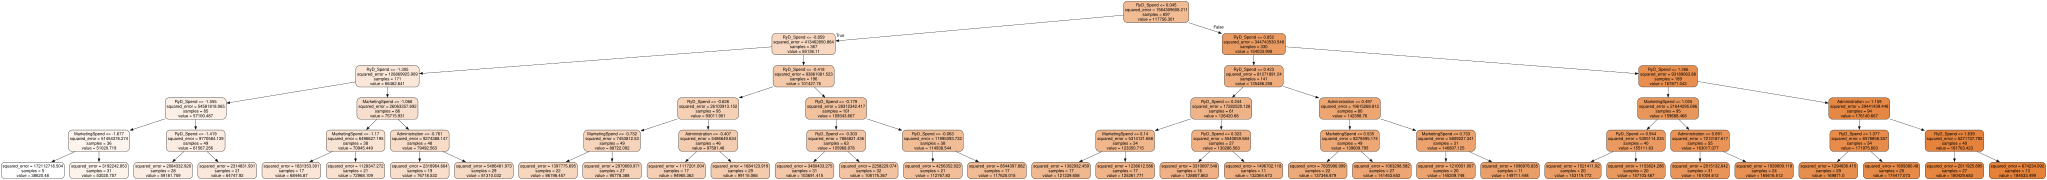

In [123]:
export_graphviz(
    best_tree_70,
    out_file="tree_regression.dot",
    feature_names=X_train_70_scaled.columns,
    rounded=True,
    filled=True
)

tree_graph = Source.from_file("tree_regression.dot")

tree_graph

Para facilitar la lectura del árbol, exportamos la visualización generada con Graphviz. En el notebook puede aparecer con un tamaño elevado, pero el archivo exportado permite observar la estructura completa del modelo y revisar con mayor detalle las particiones realizadas.

In [124]:
tree_graph.render("tree_regression", format="pdf", cleanup=True)

'tree_regression.pdf'

### Conclusión del Modelo de Regresión

A partir de la exploración de hiperparámetros, seleccionamos como mejor configuración del árbol de decisión 'max_depth=5', 'min_samples_leaf=5' y 'min_samples_split=5'. Esta combinación permitió reducir considerablemente los errores respecto del modelo base y mantuvo buenos resultados en las dos particiones evaluadas.

En la partición 80/20 obtuvimos un MAE aproximado de 1794 y un RMSE cercano a 3581, mientras que en la partición 70/30 los errores fueron menores, con un MAE aproximado de 1559 y un RMSE cercano a 3034. Si bien la partición 70/30 presentó el mejor desempeño, ambas evaluaciones muestran que la configuración seleccionada logra estimaciones precisas en relación con la escala de 'Profit'.

Al visualizar el árbol entrenado con la partición 70/30, observamos que 'RyD_Spend' ocupa el lugar central en la estructura del modelo. Esta variable aparece en la raíz y en varias divisiones posteriores, lo cual coincide con el análisis exploratorio previo, donde habíamos observado una relación muy fuerte entre el gasto en investigación y desarrollo y la ganancia. 'MarketingSpend' y 'Administration' también intervienen en algunas particiones, aunque con un rol secundario.

En cambio, las variables asociadas a 'State' no aparecen como divisiones relevantes en el árbol obtenido. Esto también resulta coherente con el boxplot analizado previamente, donde no observábamos diferencias demasiado marcadas en la distribución de 'Profit' según el estado.

En conclusión, consideramos que el árbol de decisión con la configuración seleccionada representa adecuadamente el comportamiento general del dataset luego de la limpieza realizada. El modelo logra errores relativamente bajos en relación con la escala de 'Profit', conserva una estructura interpretable y confirma que 'RyD_Spend' es la variable con mayor peso para estimar la ganancia en este conjunto de datos.